In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.version.cuda)
print(torch.cuda.get_arch_list())


True
NVIDIA GeForce RTX 5080
12.8
['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# seed = 2
# torch.manual_seed(seed)
# np.random.seed(seed)
#
# torch.cuda.manual_seed(seed)
# torch.cuda.manual_seed_all(seed)
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

In [4]:
exclude_rgb_vis=False
exclude_weather_features=True
exclude_canopy_temp=True
dataset_name = "stratified_train_test_datasets_v3.xlsx"

In [5]:
from features import *

vi_features = get_vi_features(exclude_rgb_vis=exclude_rgb_vis)
weather_features = get_weather_features(exclude=exclude_weather_features)
canopy_temp_features = get_canopy_temp_features(exclude=exclude_canopy_temp)
features = vi_features + weather_features + canopy_temp_features

output_variable = get_output_variable()


Text(0.5, 1.0, 'Train vs Test Yield Distribution')

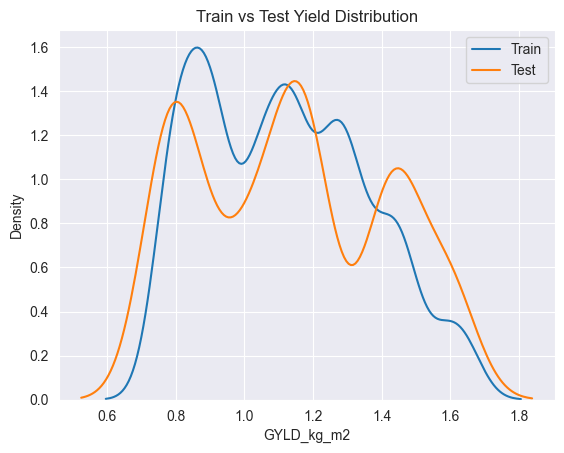

In [6]:
# Loading saved training test
train_df = pd.read_excel(f"data/{dataset_name}", sheet_name='Train')
test_df = pd.read_excel(f"data/{dataset_name}", sheet_name='Test')

sns.kdeplot(train_df[output_variable], label='Train')
sns.kdeplot(test_df[output_variable], label='Test')
plt.legend()
plt.title("Train vs Test Yield Distribution")

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

scaler_X = StandardScaler()
scaler_y = RobustScaler()

# Fit on training features and yield only
scaler_X.fit(train_df[features])
scaler_y.fit(train_df[[output_variable]])

train_df_scaled = train_df.copy()
test_df_scaled  = test_df.copy()

# --- Scaled features and target variable---
train_df_scaled[features] = scaler_X.transform(train_df[features])
train_df_scaled[output_variable] = scaler_y.transform(train_df[[output_variable]])

test_df_scaled[features] = scaler_X.transform(test_df[features])
test_df_scaled[output_variable] = scaler_y.transform(test_df[[output_variable]])

In [8]:

num_na_rows = train_df_scaled.isna().any(axis=1).sum()
print(f"train_df_scaled Rows with at least one NaN: {num_na_rows}")

num_na_rows = test_df_scaled.isna().any(axis=1).sum()
print(f"test_df_scaled Rows with at least one NaN: {num_na_rows}")


train_df_scaled Rows with at least one NaN: 1167
test_df_scaled Rows with at least one NaN: 364


In [ ]:
# print(X_test_scaled.shape)

In [9]:
from train_eval_functions import train_data, evaluate_model
import optuna
from torch.utils.data import DataLoader
from helper import make_progressive_windows, filter_window_by_length_range
from model_definitions import GRUModel
from vi_dataset import VIDataset

C:\Users\lochana.marasingha\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
window_size = 30
pad_value = 0

In [ ]:


#cols_to_pad = canopy_temp_features
#train_df_scaled[cols_to_pad] = train_df_scaled[cols_to_pad].fillna(pad_value)
#test_df_scaled[cols_to_pad] = test_df_scaled[cols_to_pad].fillna(pad_value)


In [11]:

X_train_scaled, y_train_scaled, valid_length_train, no_days_train = make_progressive_windows(
        dataframe=train_df_scaled,
        features=features,
        output_variable=output_variable,
        window_size=window_size,
        pad_value=pad_value)

X_test_scaled, y_test_scaled, valid_length_test, no_days_test  = make_progressive_windows(
    dataframe=test_df_scaled,
    features=features,
    output_variable=output_variable,
    window_size=window_size,
    pad_value=pad_value)


Processing plot 10_d
Processing plot 10_w
Processing plot 11_d
Processing plot 11_w
Processing plot 12_d
Processing plot 12_w
Processing plot 13_d
Processing plot 13_w
Processing plot 14_w
Processing plot 15_d
Processing plot 15_w
Processing plot 16_w
Processing plot 17_d
Processing plot 18_d
Processing plot 19_d
Processing plot 19_w
Processing plot 1_w
Processing plot 20_w
Processing plot 21_d
Processing plot 21_w
Processing plot 22_w
Processing plot 23_d
Processing plot 24_d
Processing plot 24_w
Processing plot 2_d
Processing plot 2_w
Processing plot 3_d
Processing plot 3_w
Processing plot 4_d
Processing plot 5_d
Processing plot 5_w
Processing plot 6_d
Processing plot 7_w
Processing plot 8_d
Processing plot 8_w
Processing plot 9_d
Processing plot 9_w
Processing plot 14_d
Processing plot 16_d
Processing plot 17_w
Processing plot 18_w
Processing plot 1_d
Processing plot 20_d
Processing plot 23_w
Processing plot 4_w
Processing plot 6_w
Processing plot 7_d


In [12]:
from helper import filter_window_by_length_range

filter_day_max = 40
filter_day_min = 1

X_train_scaled_filtered, y_train_scaled_filtered, lengths_train_filtered = filter_window_by_length_range(
    X_train_scaled, y_train_scaled, valid_length_train, no_days_train, filter_day_min, filter_day_max
    )

# test
X_test_scaled_filtered, y_test_scaled_filtered, lengths_test_filtered = filter_window_by_length_range(
    X_test_scaled, y_test_scaled, valid_length_test, no_days_test, filter_day_min, filter_day_max
)

In [13]:

train_dataset = VIDataset(X_train_scaled_filtered, y_train_scaled_filtered, lengths_train_filtered)
test_dataset = VIDataset(X_test_scaled_filtered, y_test_scaled_filtered, lengths_test_filtered)

In [14]:
from train_eval_functions import validation_with_test

epochs = 1000

def hyper_param_objective(trial):
    hidden_size = trial.suggest_categorical('hidden_size', [8, 16, 32 , 64])
    num_layers = trial.suggest_categorical('num_layers', [1, 2, 3])
    dropout = trial.suggest_float('dropout', 0.0,  0.5)
    lr = trial.suggest_float('lr', 1e-4,  1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-10, 1e-3, log=True)
    # bidirectional = trial.suggest_categorical('bidirectional', [True, False])
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])

    mean_r2 = validation_with_test(
        trial_id = trial.number,
        train_dataset = train_dataset,
        test_dataset = test_dataset,
        features = features,
        scaler_y=scaler_y,
        batch_size= batch_size,
        num_epochs=epochs,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        bidirectional=False,
        learning_rate=lr,
        weight_decay=weight_decay,
        hyper_param_criterion_method="L1Loss")
    return mean_r2


In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(hyper_param_objective, n_trials=180)

print(f"Best R²: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)

[I 2025-11-24 18:04:30,542] A new study created in memory with name: no-name-3c5dd670-1c83-4a0e-949d-bf4d21739c27
C:\Users\lochana.marasingha\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.11406384102795075 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


Epoch [1/1000] - Train Loss: 0.13992
Epoch [2/1000] - Train Loss: 0.12157
Epoch [3/1000] - Train Loss: 0.11432
Epoch [4/1000] - Train Loss: 0.11041
Epoch [5/1000] - Train Loss: 0.10869
Epoch [6/1000] - Train Loss: 0.10527
Epoch [7/1000] - Train Loss: 0.10240
Epoch [8/1000] - Train Loss: 0.10020
Epoch [9/1000] - Train Loss: 0.09824
Epoch [10/1000] - Train Loss: 0.09472
Epoch [11/1000] - Train Loss: 0.09231
Epoch [12/1000] - Train Loss: 0.08929
Epoch [13/1000] - Train Loss: 0.08733
Epoch [14/1000] - Train Loss: 0.08494
Epoch [15/1000] - Train Loss: 0.08132
Epoch [16/1000] - Train Loss: 0.07851
Epoch [17/1000] - Train Loss: 0.07820
Epoch [18/1000] - Train Loss: 0.07463
Epoch [19/1000] - Train Loss: 0.07225
Epoch [20/1000] - Train Loss: 0.06988
Epoch [21/1000] - Train Loss: 0.06759
Epoch [22/1000] - Train Loss: 0.06555
Epoch [23/1000] - Train Loss: 0.06402
Epoch [24/1000] - Train Loss: 0.06144
Epoch [25/1000] - Train Loss: 0.05984
Epoch [26/1000] - Train Loss: 0.05795
Epoch [27/1000] - Tra

[I 2025-11-24 18:06:53,312] Trial 0 finished with value: -0.023949265480041504 and parameters: {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.11406384102795075, 'lr': 0.00026533001141763505, 'weight_decay': 4.385768453550047e-09, 'batch_size': 8}. Best is trial 0 with value: -0.023949265480041504.


Epoch [605/1000] - Train Loss: 0.00079
Early stopping triggered.
 R²: -0.0239
Epoch [1/1000] - Train Loss: 0.18177
Epoch [2/1000] - Train Loss: 0.13738
Epoch [3/1000] - Train Loss: 0.13162
Epoch [4/1000] - Train Loss: 0.13075
Epoch [5/1000] - Train Loss: 0.12889
Epoch [6/1000] - Train Loss: 0.12595
Epoch [7/1000] - Train Loss: 0.12358
Epoch [8/1000] - Train Loss: 0.12142
Epoch [9/1000] - Train Loss: 0.11946
Epoch [10/1000] - Train Loss: 0.11631
Epoch [11/1000] - Train Loss: 0.11460
Epoch [12/1000] - Train Loss: 0.11263
Epoch [13/1000] - Train Loss: 0.11063
Epoch [14/1000] - Train Loss: 0.10907
Epoch [15/1000] - Train Loss: 0.10758
Epoch [16/1000] - Train Loss: 0.10703
Epoch [17/1000] - Train Loss: 0.10475
Epoch [18/1000] - Train Loss: 0.10108
Epoch [19/1000] - Train Loss: 0.10132
Epoch [20/1000] - Train Loss: 0.09940
Epoch [21/1000] - Train Loss: 0.09766
Epoch [22/1000] - Train Loss: 0.09509
Epoch [23/1000] - Train Loss: 0.09460
Epoch [24/1000] - Train Loss: 0.09169
Epoch [25/1000] - T

[I 2025-11-24 18:07:10,838] Trial 1 finished with value: 0.08372551202774048 and parameters: {'hidden_size': 32, 'num_layers': 2, 'dropout': 0.14126204838506268, 'lr': 0.0004440518362409316, 'weight_decay': 1.387894371953807e-07, 'batch_size': 64}. Best is trial 1 with value: 0.08372551202774048.


...

Epoch [6/1000] - Train Loss: 0.10896
Epoch [7/1000] - Train Loss: 0.10259
Epoch [8/1000] - Train Loss: 0.09943
Epoch [9/1000] - Train Loss: 0.09511
Epoch [10/1000] - Train Loss: 0.08950
Epoch [11/1000] - Train Loss: 0.08709
Epoch [12/1000] - Train Loss: 0.08293
Epoch [13/1000] - Train Loss: 0.07931
Epoch [14/1000] - Train Loss: 0.07655
Epoch [15/1000] - Train Loss: 0.07167
Epoch [16/1000] - Train Loss: 0.06675
Epoch [17/1000] - Train Loss: 0.06123
Epoch [18/1000] - Train Loss: 0.05754
Epoch [19/1000] - Train Loss: 0.05554
Epoch [20/1000] - Train Loss: 0.05210
Epoch [21/1000] - Train Loss: 0.04948
Epoch [22/1000] - Train Loss: 0.04724
Epoch [23/1000] - Train Loss: 0.04469
Epoch [24/1000] - Train Loss: 0.04405
Epoch [25/1000] - Train Loss: 0.04164
Epoch [26/1000] - Train Loss: 0.04129
Epoch [27/1000] - Train Loss: 0.03786
Epoch [28/1000] - Train Loss: 0.03970
Epoch [29/1000] - Train Loss: 0.03816
Epoch [30/1000] - Train Loss: 0.03762
Epoch [31/1000] - Train Loss: 0.03390
Epoch [32/1000] 

[I 2025-11-24 18:09:45,128] Trial 5 finished with value: -0.5227247476577759 and parameters: {'hidden_size': 16, 'num_layers': 1, 'dropout': 0.0741840339361991, 'lr': 0.002714132016524869, 'weight_decay': 6.114312810003222e-06, 'batch_size': 64}. Best is trial 1 with value: 0.08372551202774048.


Epoch [456/1000] - Train Loss: 0.00335
Epoch [457/1000] - Train Loss: 0.00329
Epoch [458/1000] - Train Loss: 0.00332
Early stopping triggered.
 R²: -0.5227
Epoch [1/1000] - Train Loss: 0.13730
Epoch [2/1000] - Train Loss: 0.11678
Epoch [3/1000] - Train Loss: 0.11174
Epoch [4/1000] - Train Loss: 0.10815
Epoch [5/1000] - Train Loss: 0.10184
Epoch [6/1000] - Train Loss: 0.09393
Epoch [7/1000] - Train Loss: 0.08976
Epoch [8/1000] - Train Loss: 0.08351
Epoch [9/1000] - Train Loss: 0.07631
Epoch [10/1000] - Train Loss: 0.07145
Epoch [11/1000] - Train Loss: 0.06355
Epoch [12/1000] - Train Loss: 0.05365
Epoch [13/1000] - Train Loss: 0.04810
Epoch [14/1000] - Train Loss: 0.04427
Epoch [15/1000] - Train Loss: 0.04062
Epoch [16/1000] - Train Loss: 0.03877
Epoch [17/1000] - Train Loss: 0.03560
Epoch [18/1000] - Train Loss: 0.03417
Epoch [19/1000] - Train Loss: 0.03231
Epoch [20/1000] - Train Loss: 0.03067
Epoch [21/1000] - Train Loss: 0.02704
Epoch [22/1000] - Train Loss: 0.02691
Epoch [23/1000] -

[I 2025-11-24 18:11:01,607] Trial 6 finished with value: 0.18659085035324097 and parameters: {'hidden_size': 32, 'num_layers': 2, 'dropout': 0.34473795398401685, 'lr': 0.0008688754279294404, 'weight_decay': 1.5360328117838793e-09, 'batch_size': 8}. Best is trial 6 with value: 0.18659085035324097.


Epoch [276/1000] - Train Loss: 0.00147
Early stopping triggered.
 R²: 0.1866
Epoch [1/1000] - Train Loss: 0.13574
Epoch [2/1000] - Train Loss: 0.12603
Epoch [3/1000] - Train Loss: 0.12296
Epoch [4/1000] - Train Loss: 0.11853
Epoch [5/1000] - Train Loss: 0.11386
Epoch [6/1000] - Train Loss: 0.10990
Epoch [7/1000] - Train Loss: 0.10843
Epoch [8/1000] - Train Loss: 0.10445
Epoch [9/1000] - Train Loss: 0.10413
Epoch [10/1000] - Train Loss: 0.10298
Epoch [11/1000] - Train Loss: 0.10294
Epoch [12/1000] - Train Loss: 0.10082
Epoch [13/1000] - Train Loss: 0.09861
Epoch [14/1000] - Train Loss: 0.09832


In [ ]:
# =============================================
#  Train the best model with best hyper params
# =============================================
from model_definitions import GRUModel

# Filtered day min 1 to day max 40
# Dataset: v3
# Features: All the VIs in v3 dataset
# Masking/Length in GRU: False;  Make sure GRU model does not use lengths in the forward function
# Pad = 0
# criterion_method = L1 Loss
# best_gru_params = {'hidden_size': 8, 'num_layers': 3, 'dropout': 0.07118372737795423, 'lr': 0.006619597606393245, 'weight_decay': 5.754964001654844e-10, 'batch_size': 8}

best_model = GRUModel(
    input_size=len(features),
    hidden_size=best_gru_params['hidden_size'],
    num_layers=best_gru_params['num_layers'],
    output_size=1,
    dropout=best_gru_params['dropout'],
    bidirectional=False).to(device)

In [ ]:
train_loader  = DataLoader(train_dataset, batch_size=best_gru_params['batch_size'], shuffle=True)
test_loader    = DataLoader(test_dataset, batch_size=best_gru_params['batch_size'], shuffle=False)

In [ ]:
# Optional: Train again with best hyper parameters

epochs = 200
criterion_method="L1Loss"

train_losses = train_data(
            model = best_model,
            model_train_loader= train_loader,
            num_epochs = epochs,
            learning_rate = best_gru_params['lr'],
            weight_decay = best_gru_params['weight_decay'],
            hyper_param_criterion_method = criterion_method,
            file_save_name ="best_model_gru2.pth",
            early_stopping = False,
        )


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, 200+1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()

In [ ]:
best_model.load_state_dict(torch.load("best_gru_models/best_model_hyper_param90.pth", map_location=device))

# Training metrics
r2_train, mse_train, mae_train = evaluate_model(best_model, train_loader, output_variable_scaler=scaler_y, do_inverse_transform= True, plot_pred_vs_true=True)
# Test metrics
r2_test, mse_test, mae_test = evaluate_model(best_model, test_loader, output_variable_scaler=scaler_y, do_inverse_transform= True, plot_pred_vs_true=True)

print(f'Train R²: {r2_train:.4f}, Train MSE: {mse_train:.4f}')
print(f'Test R²: {r2_test:.4f}, Test MSE: {mse_test:.4f}')


In [ ]:
from helper import filter_window_data_by_length

total_n_days = 40

test_r2 = []
test_mse = []
test_mae = []
for filter_day in range(1, total_n_days + 1):
    print(f"day: {filter_day}")

    X_train_scaled_filtered, y_train_scaled_filtered, lengths_train_filtered = filter_window_data_by_length(
    X_train_scaled, y_train_scaled, valid_length_train, no_days_train, filter_day
    )

    # test
    X_test_scaled_filtered, y_test_scaled_filtered, lengths_test_filtered = filter_window_data_by_length(
        X_test_scaled, y_test_scaled, valid_length_test, no_days_test, filter_day
    )

    train_dataset_filtered = VIDataset(X_train_scaled_filtered, y_train_scaled_filtered, lengths_train_filtered)
    test_dataset_filtered = VIDataset(X_test_scaled_filtered, y_test_scaled_filtered, lengths_test_filtered)

    train_loader_filtered  = DataLoader(train_dataset_filtered, batch_size=best_gru_params['batch_size'], shuffle=True)
    test_loader_filtered    = DataLoader(test_dataset_filtered, batch_size=best_gru_params['batch_size'], shuffle=False)

    # Training metrics
    r2_train_filtered, mse_train_filtered, mae_train_filtered = evaluate_model(best_model, train_loader_filtered, output_variable_scaler=scaler_y, do_inverse_transform = True,  plot_pred_vs_true=False)
    # Test metrics
    r2_test_filtered, mse_test_filtered, mae_test_filtered = evaluate_model(best_model, test_loader_filtered, output_variable_scaler=scaler_y,
                                                                            do_inverse_transform = True,  plot_pred_vs_true=False)

    print(f'Train R²: {r2_train_filtered:.4f}, Train MSE: {mse_train_filtered:.4f}, Train MAE: {mae_train_filtered:.4f}')
    print(f'Test R²: {r2_test_filtered:.4f}, Test MSE: {mse_test_filtered:.4f}, Test MAE: {mae_test_filtered:.4f}')
    test_r2.append(r2_test_filtered)
    test_mse.append(mse_test_filtered)
    test_mae.append(mae_test_filtered)


In [ ]:
import numpy as np

print(np.mean(test_r2))
print(np.min(test_r2))
print(np.max(test_r2))

print(np.mean(test_mse))
print(np.max(test_mse))
print(np.min(test_mse))

In [ ]:
from plots import plot_r2, plot_mse

plot_r2(test_r2, total_n_days)
plot_mse(test_mse, total_n_days)

In [ ]:
# save model
torch.save(best_model, "best_gru_models/best_model_full_5.pth")

# save Scalers for future predictions
import joblib

joblib.dump(scaler_X, "best_gru_models/scalers/scaler_X_5.save")
joblib.dump(scaler_y, "best_gru_models/scalers/scaler_y_5.save")